# Chapter 69 — Parameter Sensitivity

> **Prerequisites:** ch066–067 (Transformations, Scaling)
>
> **You will learn:**
> - Measure how function outputs change with respect to parameter changes
> - Implement numerical sensitivity analysis
> - Connect to hyperparameter tuning in ML
> - Preview partial derivatives (formalized in ch210)
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Parameter sensitivity** measures how much the output of a function changes when a parameter is varied.

If f(x; θ) is a function parameterized by θ, sensitivity is roughly:
Δf / Δθ — the change in output per unit change in parameter.

For continuous θ, this is the partial derivative ∂f/∂θ.

**Why it matters:**
- In ML, models have hyperparameters (learning rate, regularization strength, layer size). Sensitivity tells you which ones matter most.
- In engineering, sensitivity analysis identifies which parameters drive uncertainty in a design.
- In simulations, it tells you where small input errors cause large output errors.

**Types of sensitivity:**
- **Local**: how f changes near a specific θ value (derivative-based)
- **Global**: how f varies across the entire parameter space (sampling-based)

---

## 2. Intuition & Mental Models

**Physical analogy:** A building's sensitivity to wind. Small changes in wind speed may cause large or small structural response, depending on the frequency. Sensitivity analysis finds the dangerous frequencies.

**Computational analogy:** Hyperparameter search in ML is empirical sensitivity analysis. You vary the learning rate, observe the loss, and identify the range where the model is stable.

---

## 3. Visualization

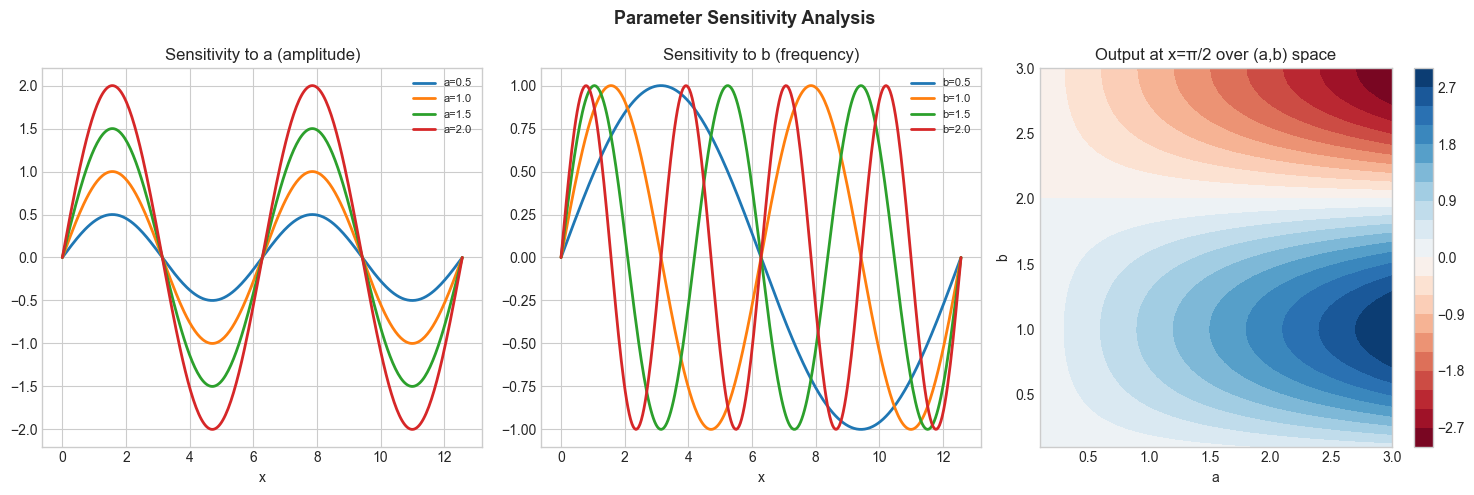

In [1]:
# --- Visualization: Parameter sensitivity surfaces ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# f(x; a, b) = a * sin(b * x) -- two parameters
def f(x, a, b): return a * np.sin(b * x)

x = np.linspace(0, 4*np.pi, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Vary parameter a (amplitude)
ax = axes[0]
for a in [0.5, 1.0, 1.5, 2.0]:
    ax.plot(x, f(x, a, 1), linewidth=2, label=f'a={a}')
ax.set_title('Sensitivity to a (amplitude)'); ax.legend(fontsize=8); ax.set_xlabel('x')

# Vary parameter b (frequency)
ax = axes[1]
for b in [0.5, 1.0, 1.5, 2.0]:
    ax.plot(x, f(x, 1, b), linewidth=2, label=f'b={b}')
ax.set_title('Sensitivity to b (frequency)'); ax.legend(fontsize=8); ax.set_xlabel('x')

# Sensitivity heatmap: output at x=π/2 over (a, b) grid
ax = axes[2]
a_vals = np.linspace(0.1, 3, 50)
b_vals = np.linspace(0.1, 3, 50)
A, B = np.meshgrid(a_vals, b_vals)
Z = f(np.pi/2, A, B)
im = ax.contourf(A, B, Z, levels=20, cmap='RdBu')
plt.colorbar(im, ax=ax)
ax.set_title('Output at x=π/2 over (a,b) space'); ax.set_xlabel('a'); ax.set_ylabel('b')

plt.suptitle('Parameter Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Numerical sensitivity analysis ---
import numpy as np

def local_sensitivity(f, params, param_idx, h=1e-5):
    """
    Compute local sensitivity of f with respect to params[param_idx].
    Uses central finite difference: (f(θ+h) - f(θ-h)) / (2h).
    
    Args:
        f: callable, takes params as positional args
        params: list of parameter values
        param_idx: index of parameter to differentiate
        h: finite difference step size
    Returns:
        float: ∂f/∂θ_i at current params
    """
    p_plus = params.copy()
    p_minus = params.copy()
    p_plus[param_idx] += h
    p_minus[param_idx] -= h
    return (f(*p_plus) - f(*p_minus)) / (2 * h)

def sensitivity_report(f, params, param_names):
    """Compute sensitivity of f to each parameter and rank by magnitude."""
    sensitivities = []
    for i, name in enumerate(param_names):
        s = local_sensitivity(f, list(params), i)
        sensitivities.append((name, s, abs(s)))
    return sorted(sensitivities, key=lambda x: -x[2])

# Example: logistic growth model
# f(K, r, t0) = K / (1 + exp(-r*(t - t0)))
t_fixed = 30
logistic = lambda K, r, t0: K / (1 + np.exp(-r * (t_fixed - t0)))
params = [10000.0, 0.15, 25.0]
names = ['K (capacity)', 'r (growth rate)', 't0 (midpoint)']

print("Sensitivity at t=30:")
for name, s, abs_s in sensitivity_report(logistic, params, names):
    print(f"  ∂f/∂{name} = {s:.4f}  (magnitude: {abs_s:.4f})")

Sensitivity at t=30:
  ∂f/∂r (growth rate) = 10894.7497  (magnitude: 10894.7497)
  ∂f/∂t0 (midpoint) = -326.8425  (magnitude: 326.8425)
  ∂f/∂K (capacity) = 0.6792  (magnitude: 0.6792)


---

## 6. Experiments

**Experiment 1:** Run the sensitivity report for the logistic model at different time points t=10, 20, 30, 40, 50. How does sensitivity to each parameter change across time?

**Experiment 2:** For f(x) = sin(ax), plot ∂f/∂a as a function of x for a=1. Where is f most sensitive to changes in a?

---

## 7. Exercises

**Easy 1.** For f(x) = x^a, compute ∂f/∂a at x=2, a=3. Verify your analytical answer matches the finite-difference estimate.

**Easy 2.** The learning rate η is a hyperparameter in gradient descent: x_new = x - η*gradient. Compute how sensitive the update step is to η (i.e., ∂(x_new)/∂η).

**Medium 1.** Implement `global_sensitivity(f, param_ranges, n_samples=500)` using Monte Carlo: sample all parameters uniformly from their ranges and compute variance of f output. Parameters whose individual variance (vary one, fix others) is highest drive the most output variance.

**Medium 2.** Apply sensitivity analysis to the quadratic formula: given a, b, c, which parameter does the root x₁ = (-b-√Δ)/(2a) depend on most sensitively?

**Hard.** Implement Sobol sensitivity indices numerically: a method for global parameter sensitivity that decomposes output variance into contributions from each parameter and their interactions. Apply to f(a,b,c) = a*sin(b) + c².

---

## 9. Chapter Summary & Connections

- Sensitivity = ∂f/∂θ: how much output changes per unit parameter change
- Local sensitivity: finite differences; global sensitivity: Monte Carlo sampling
- High sensitivity → parameter needs to be tuned carefully; low sensitivity → less critical
- This is the preview of partial derivatives (ch210) applied to parameterized functions

**Forward connections:**
- ch210 (Partial Derivatives) formalizes ∂f/∂θ for multivariable functions
- Hyperparameter sensitivity analysis is the practical application throughout Part IX
- Gradient computation in ch207 (Automatic Differentiation) is exact sensitivity